In [ ]:
from google.colab import files
uploaded = files.upload()  # select roman_urdu_spam_dataset.csv

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/roman_urdu_spam_dataset.csv")
print(df.shape)
print(df["label"].value_counts())
df.head()

(195, 2)
label
0    100
1     95
Name: count, dtype: int64


,message,label
0,"Bhai kal cricket khelne chalna hai, ground par...",0
1,"Ammi ki tabiyat ab theek hai, dawai se araam a...",0
2,"Mujhe airport se pick karne aa jana, flight 6 ...",0
3,"Naye semester ka schedule aa gaya hai, check k...",0
4,"Kal exam hai, shaam 5 baje par pohanch jana",0


In [ ]:
# Words that recur in the spam messages — this list is what makes the
# feature engineering "yours." Read through your dataset and refine this.
spam_words = [
    "free", "jeeta", "jeet", "prize", "claim", "offer", "sale", "discount",
    "win", "winner", "lucky", "urgent", "verify", "block", "suspend",
    "click", "link", "loan", "cash", "guaranteed", "limited", "congratulations",
    "mubarak", "bank", "account", "pin", "otp", "customs"
]

In [ ]:
def extract_features(message):
    msg = str(message)
    lower = msg.lower()

    length = len(msg)
    digit_count = sum(c.isdigit() for c in msg)
    letters = [c for c in msg if c.isalpha()]
    caps_ratio = (sum(c.isupper() for c in msg) / len(letters)) if letters else 0.0
    spam_word_count = sum(word in lower for word in spam_words)
    has_link = int(("http" in lower) or ("www" in lower) or (".com" in lower))
    # crude phone-number pattern: a run of 7+ consecutive digits
    digit_run = 0
    max_digit_run = 0
    for c in msg:
        if c.isdigit():
            digit_run += 1
            max_digit_run = max(max_digit_run, digit_run)
        else:
            digit_run = 0
    has_phone_number = int(max_digit_run >= 7)
    exclamation_count = msg.count("!")

    return [length, digit_count, caps_ratio, spam_word_count,
            has_link, has_phone_number, exclamation_count]

feature_names = ["length", "digit_count", "caps_ratio", "spam_word_count",
                  "has_link", "has_phone_number", "exclamation_count"]

# Build the feature matrix with NumPy, row by row
X = np.array([extract_features(msg) for msg in df["message"]])
y = df["label"].values

print(X.shape)          # (num_messages, num_features)
print(feature_names)
print(X[:5])             # inspect first 5 rows

(195, 7)
['length', 'digit_count', 'caps_ratio', 'spam_word_count', 'has_link', 'has_phone_number', 'exclamation_count']
[[5.30000000e+01 1.00000000e+00 2.38095238e-02 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [5.20000000e+01 0.00000000e+00 2.43902439e-02 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [6.10000000e+01 1.00000000e+00 2.04081633e-02 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [5.30000000e+01 0.00000000e+00 2.32558140e-02 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [4.30000000e+01 1.00000000e+00 3.03030303e-02 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00]]


In [ ]:
sample_spam = df[df["label"] == 1]["message"].iloc[0]
sample_ham  = df[df["label"] == 0]["message"].iloc[0]

print("SPAM example:", sample_spam)
print("Features:", extract_features(sample_spam))
print()
print("NOT-SPAM example:", sample_ham)
print("Features:", extract_features(sample_ham))

SPAM example: SALE! 60% off har item par, sirf is weekend tak, order karein abhi
Features: [66, 2, 0.08333333333333333, 1, 0, 0, 1]

NOT-SPAM example: Bhai kal cricket khelne chalna hai, ground par 5 baje
Features: [53, 1, 0.023809523809523808, 0, 0, 0, 0]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

    Not Spam       1.00      1.00      1.00        25
        Spam       1.00      1.00      1.00        24

    accuracy                           1.00        49
   macro avg       1.00      1.00      1.00        49
weighted avg       1.00      1.00      1.00        49


Confusion Matrix:
 [[25  0]
 [ 0 24]]


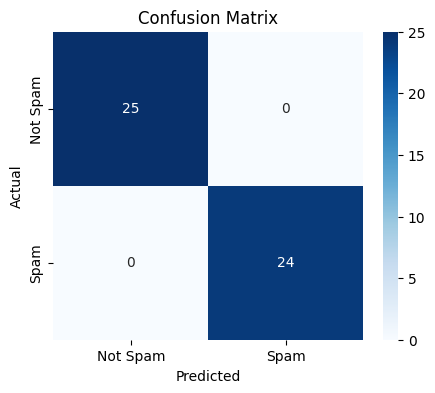

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Not Spam", "Spam"]))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Spam", "Spam"], yticklabels=["Not Spam", "Spam"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": model.coef_[0]
}).sort_values("coefficient", ascending=False)
print(coefficients)

             feature  coefficient
0             length     2.470962
3    spam_word_count     1.429087
6  exclamation_count     1.027985
1        digit_count     0.793653
2         caps_ratio     0.619698
4           has_link     0.397574
5   has_phone_number     0.314903


In [ ]:
new_messages = [
    "Kal party hai mere ghar, 7 baje aa jana",                                  # not spam
    "Aap ne 200000 jeeta hai, is number par call karein 03009876543",           # spam
    "Bhai assignment submit karna mat bhoolna kal",                             # not spam
    "URGENT: aapka account 24 ghante mein band ho jayega, verify karein abhi", # spam
    "Mummy ne bola hai raat ko jaldi ana ghar"                                  # not spam
]

new_features = np.array([extract_features(m) for m in new_messages])
new_features_scaled = scaler.transform(new_features)
predictions = model.predict(new_features_scaled)
probabilities = model.predict_proba(new_features_scaled)

for msg, pred, prob in zip(new_messages, predictions, probabilities):
    label = "SPAM" if pred == 1 else "NOT SPAM"
    confidence = prob[pred] * 100
    print(f"[{label}] ({confidence:.1f}% confident) — {msg}")

[NOT SPAM] (99.3% confident) — Kal party hai mere ghar, 7 baje aa jana
[SPAM] (97.2% confident) — Aap ne 200000 jeeta hai, is number par call karein 03009876543
[NOT SPAM] (99.1% confident) — Bhai assignment submit karna mat bhoolna kal
[SPAM] (98.1% confident) — URGENT: aapka account 24 ghante mein band ho jayega, verify karein abhi
[NOT SPAM] (99.4% confident) — Mummy ne bola hai raat ko jaldi ana ghar
